### Existe una relación lineal positiva y estadísticamente significativa entre el diametro_altura_pecho (DAP) y la altura_arbol. Esta relación es lo suficientemente fuerte como para permitir que el DAP sea utilizado como un predictor confiable de la altura del árbol.

#### Implicancia:
* Medir el DAP es fácil, rápido y barato (requiere solo una cinta métrica).
* Medir la altura_arbol es difícil, lento y caro (requiere un hipsómetro o clinómetro, personal entrenado, y es impreciso si la copa no es visible).La implicancia es la eficiencia: 
    Si probamos esta hipótesis, el cliente puede dejar de medir la altura en futuros inventarios. Podrá simplemente medir el DAP (fácil) y usar nuestro modelo para estimar la altura con un grado de precisión conocido (ej. "$\pm 1.5$ metros"). Esto ahorra miles de horas de trabajo y costos operativos.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 

In [2]:
datos_limpios= pd.read_pickle('../data/datos_arbolado')

In [4]:
datos_limpios.head()

,long,lat,comuna,manzana,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,NaN,Esmeralda,1000,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,NaN,Pellegrini Carlos,1300,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,NaN,Arroyo,800,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,NaN,Arroyo,900,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,NaN,Arroyo,900,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


In [5]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338991 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   338991 non-null  float64
 1   lat                    338991 non-null  float64
 2   comuna                 338991 non-null  float64
 3   manzana                204681 non-null  object 
 4   calle_nombre           338991 non-null  object 
 5   calle_altura           338991 non-null  int64  
 6   calle_chapa            335639 non-null  Int32  
 7   nombre_cientifico      338991 non-null  object 
 8   ancho_acera            338991 non-null  float64
 9   estado_plantera        338842 non-null  float64
 10  ubicacion_plantera     338136 non-null  object 
 11  nivel_plantera         338324 non-null  float64
 12  diametro_altura_pecho  338991 non-null  float64
 13  altura_arbol           338991 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

In [5]:
datos_limpios=datos_limpios[datos_limpios['altura_arbol'].notna()]

In [7]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338991 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   338991 non-null  float64
 1   lat                    338991 non-null  float64
 2   comuna                 338991 non-null  float64
 3   manzana                204681 non-null  object 
 4   calle_nombre           338991 non-null  object 
 5   calle_altura           338991 non-null  int64  
 6   calle_chapa            335639 non-null  Int32  
 7   nombre_cientifico      338991 non-null  object 
 8   ancho_acera            338991 non-null  float64
 9   estado_plantera        338842 non-null  float64
 10  ubicacion_plantera     338136 non-null  object 
 11  nivel_plantera         338324 non-null  float64
 12  diametro_altura_pecho  338991 non-null  float64
 13  altura_arbol           338991 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

In [12]:
datos_limpios['nombre_cientifico'].value_counts()

nombre_cientifico
Fraxinus pennsylvanica                 127973
Otra                                    54172
Platanus x acerifolia                   29960
Ficus benjamina                         21379
Tilia x moltkei                         14800
Melia azedarach                         14036
Jacaranda mimosifolia                   12790
Lagerstroemia indica                    11356
Fraxinus americana                       9621
Ligustrum lucidum                        8624
Fraxinus excelsior                       8201
Tipuana tipu                             8125
Ligustrum lucidum f. aureovariegata      7751
Liquidambar styraciflua                  5311
Acer negundo                             4892
Name: count, dtype: int64

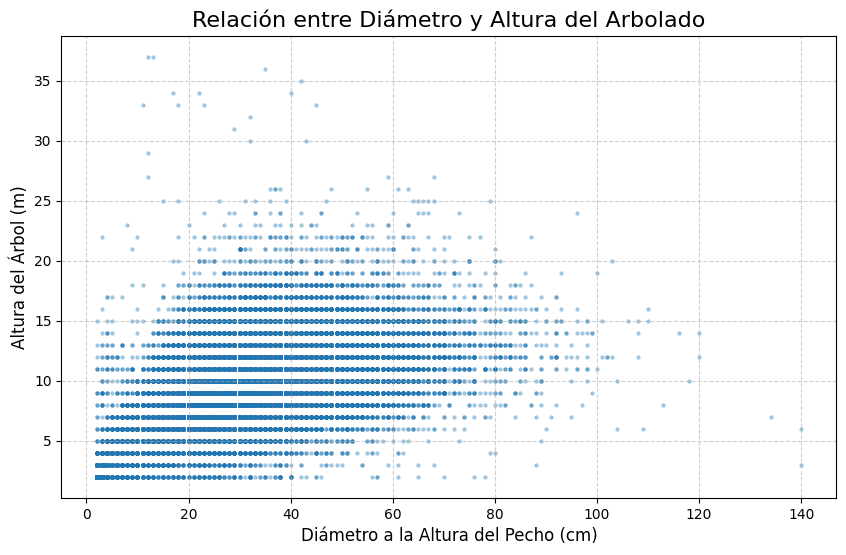

----------------------------------------
Resultados de Correlación (sobre 127965 árboles):
  Correlación de Pearson (r): 0.5085
 Correlación de Spearman (ρ): 0.5130
----------------------------------------


<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# Asumo que tu DataFrame se llama 'datos_arbolado'
# ---- 1. Limpieza y Preparación ----

# Creamos una copia para no modificar el original
df_plot = fraxinus.copy()

# (Paso de seguridad) Aseguramos que ambas columnas sean numéricas
# 'coerce' convertirá cualquier texto (como 'Sin dato') en NaN
df_plot['diametro_altura_pecho'] = pd.to_numeric(df_plot['diametro_altura_pecho'], errors='coerce')
df_plot['altura_arbol'] = pd.to_numeric(df_plot['altura_arbol'], errors='coerce')

# Eliminamos filas donde falte alguno de estos dos datos
df_plot.dropna(subset=['diametro_altura_pecho', 'altura_arbol'], inplace=True)

# ---- 2. Filtrado de Outliers ----
# Filtramos valores extremos que "aplastarían" el gráfico
# Ej: Diámetros > 200cm o Alturas > 40m
df_filtrado = df_plot[
    (df_plot['diametro_altura_pecho'] > 0) & (df_plot['diametro_altura_pecho'] < 200) &
    (df_plot['altura_arbol'] > 0) & (df_plot['altura_arbol'] < 40)
]

# ---- 3. Muestreo (Sampling) ----
# Tomamos una muestra aleatoria de 50,000 puntos para evitar el overplotting
df_sample = df_filtrado.sample(n=min(50000, len(df_filtrado)), random_state=42)

# ---- 4. Creación del Gráfico ----
plt.figure(figsize=(10, 6))
plt.scatter(
    df_sample['diametro_altura_pecho'],
    df_sample['altura_arbol'],
    alpha=0.3,  # Transparencia para ver la densidad
    s=5         # Tamaño pequeño del punto
)

plt.title('Relación entre Diámetro y Altura del Arbolado', fontsize=16)
plt.xlabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.ylabel('Altura del Árbol (m)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()

# ---- 3. Muestreo (Sampling) ----
# ... (tu código de muestreo para el gráfico) ...
df_sample = df_filtrado.sample(n=min(50000, len(df_filtrado)), random_state=42)

# ==========================================================
# AÑADIR AQUÍ EL CÁLCULO DE CORRELACIÓN
# ==========================================================
# Usamos df_filtrado (todos los datos limpios) para el cálculo estadístico

# --- Método 1: Correlación de Pearson (la más común) ---
# Mide la relación LINEAL
corr_pearson = df_filtrado['diametro_altura_pecho'].corr(
    df_filtrado['altura_arbol'], 
    method='pearson'
)

# --- Método 2: Correlación de Spearman ---
# Mide la relación MONOTÓNICA (si una sube, la otra también, 
# aunque no sea una línea recta). Es útil si la relación se "aplana".
corr_spearman = df_filtrado['diametro_altura_pecho'].corr(
    df_filtrado['altura_arbol'], 
    method='spearman'
)

print("-" * 40)
print(f"Resultados de Correlación (sobre {len(df_filtrado)} árboles):")
print(f"  Correlación de Pearson (r): {corr_pearson:.4f}")
print(f" Correlación de Spearman (ρ): {corr_spearman:.4f}")
print("-" * 40)
# ==========================================================

# ---- 4. Creación del Gráfico ----
# (Tu código de plt.scatter() sigue aquí, usando df_sample)
plt.figure(figsize=(10, 6))
# ... (el resto de tu código de plotting) ...

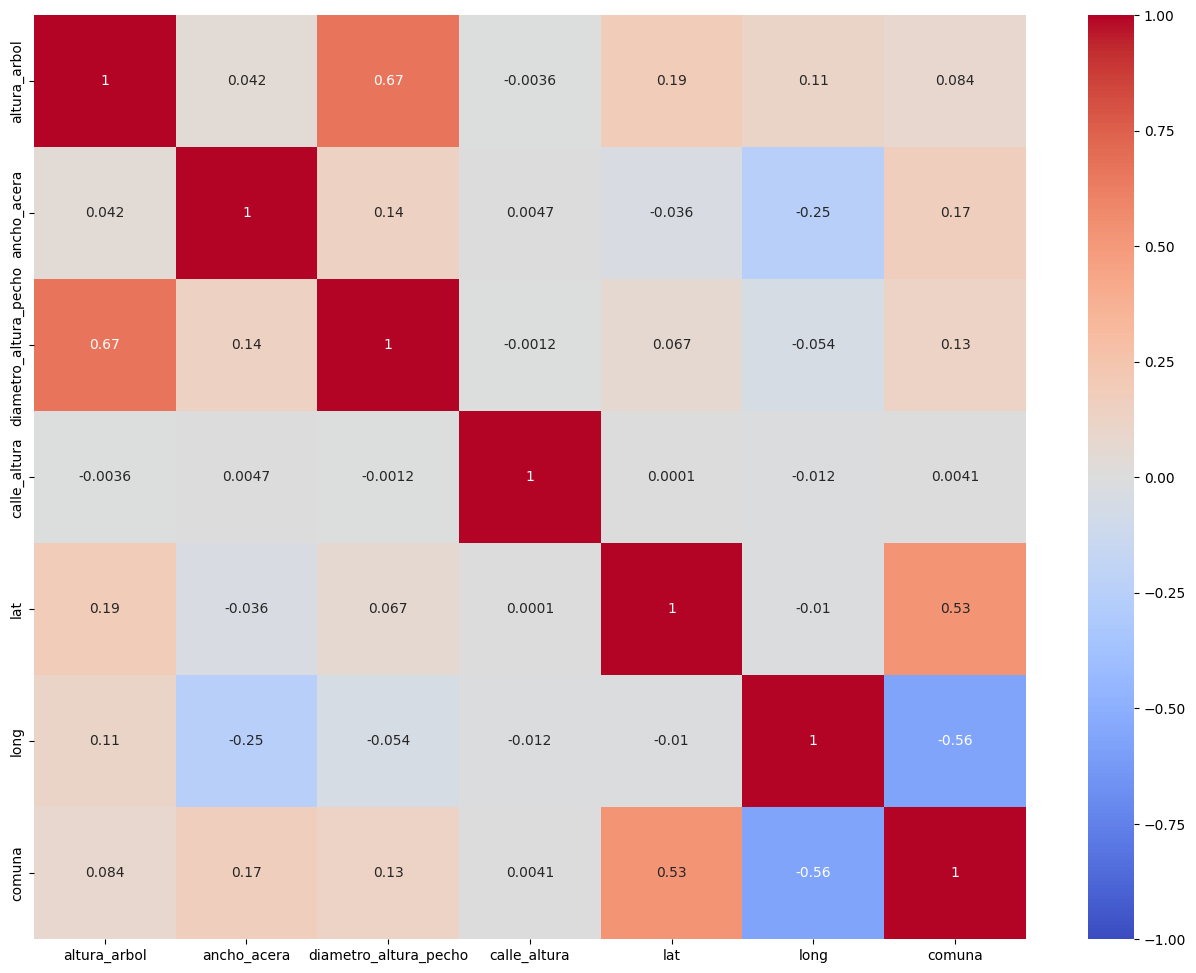

In [ ]:
dato=datos_limpios[['altura_arbol', 'ancho_acera', 'diametro_altura_pecho','calle_altura','lat','long','comuna']].corr(method='pearson')


import seaborn as sns
import matplotlib.pyplot as plt

# imprimimos la matriz como un heatmap
plt.figure(figsize=(16,12))
sns.heatmap(dato, vmin=-1.0, vmax=1.0, center=0.0, annot=True, cmap= 'coolwarm')
plt.show()

In [10]:
datos_limpios.info()

<class 'pandas.core.frame.DataFrame'>
Index: 338991 entries, 0 to 370055
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   long                   338991 non-null  float64
 1   lat                    338991 non-null  float64
 2   comuna                 338991 non-null  float64
 3   manzana                204681 non-null  object 
 4   calle_nombre           338991 non-null  object 
 5   calle_altura           338991 non-null  int64  
 6   calle_chapa            335639 non-null  Int32  
 7   nombre_cientifico      338991 non-null  object 
 8   ancho_acera            338991 non-null  float64
 9   estado_plantera        338842 non-null  float64
 10  ubicacion_plantera     338136 non-null  object 
 11  nivel_plantera         338324 non-null  float64
 12  diametro_altura_pecho  338991 non-null  float64
 13  altura_arbol           338991 non-null  float64
dtypes: Int32(1), float64(8), int64(1), object

**Probando con el modelo de regresion lineal el estadistico f da un nomero favorable, pero por test omnibus se rechaza la hipotesis de que los residuios se distribuyen normal** 

In [24]:
import numpy as np
import statsmodels.api as sm
datos_limpios= datos_limpios[datos_limpios['estado_plantera'].notna()]
# Separamos nuestra variable independiente
X = datos_limpios[['diametro_altura_pecho','ancho_acera','altura_arbol']]
# y nuestra variable objetivo (variable dependiente)
y = datos_limpios['estado_plantera']

# Agregamos una constante como característica, para estimar la ordenada al origen
X = sm.add_constant(X)
# Ajustamos el modelo
model = sm.OLS(y, X).fit()
# Imprimimos el resumen de los resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        estado_plantera   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     2552.
Date:                Sat, 08 Nov 2025   Prob (F-statistic):               0.00
Time:                        00:05:54   Log-Likelihood:                -75647.
No. Observations:              338842   AIC:                         1.513e+05
Df Residuals:                  338838   BIC:                         1.513e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.08